In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r'..\data\cleaned\Global_Superstore_Cleaned.csv'
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping Days
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,0
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,1
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,1


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(51290, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    512

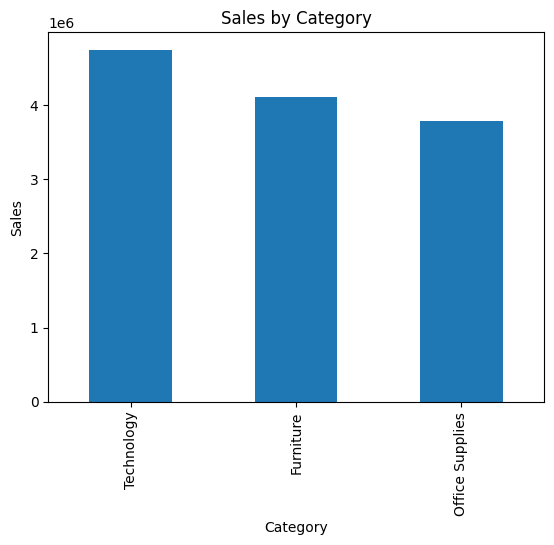

In [4]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

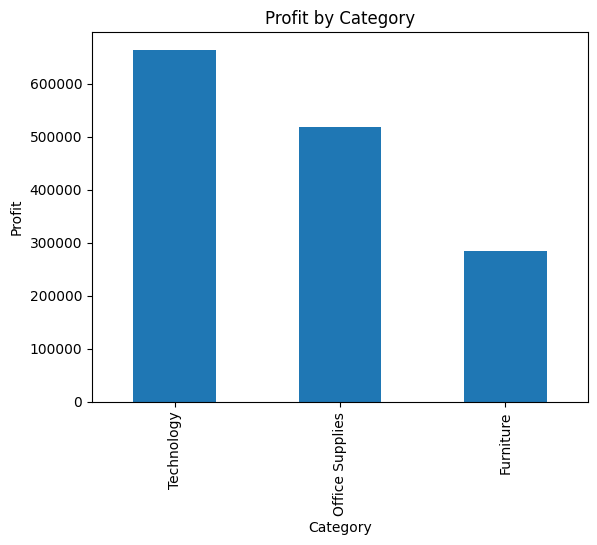

In [5]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.ylabel('Profit')
plt.show()

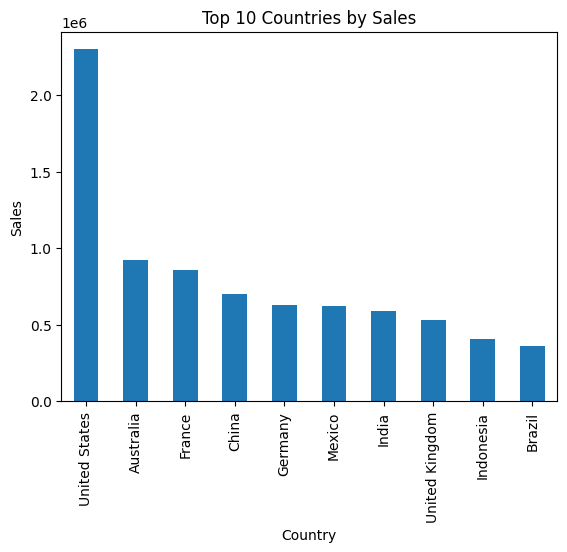

In [6]:
top_countries = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Sales')
plt.ylabel('Sales')
plt.show()

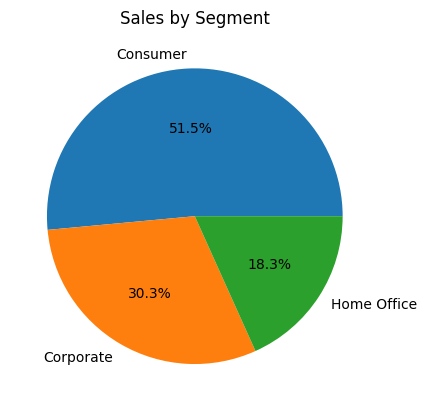

In [7]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Segment')
plt.ylabel('')
plt.show()

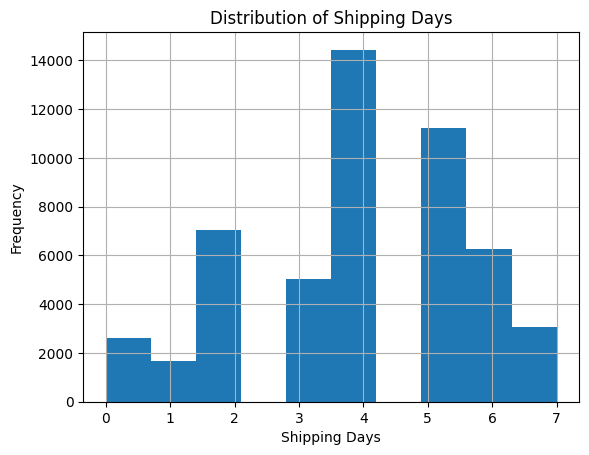

In [8]:
df['Shipping Days'].hist()
plt.title('Distribution of Shipping Days')
plt.xlabel('Shipping Days')
plt.ylabel('Frequency')
plt.show()

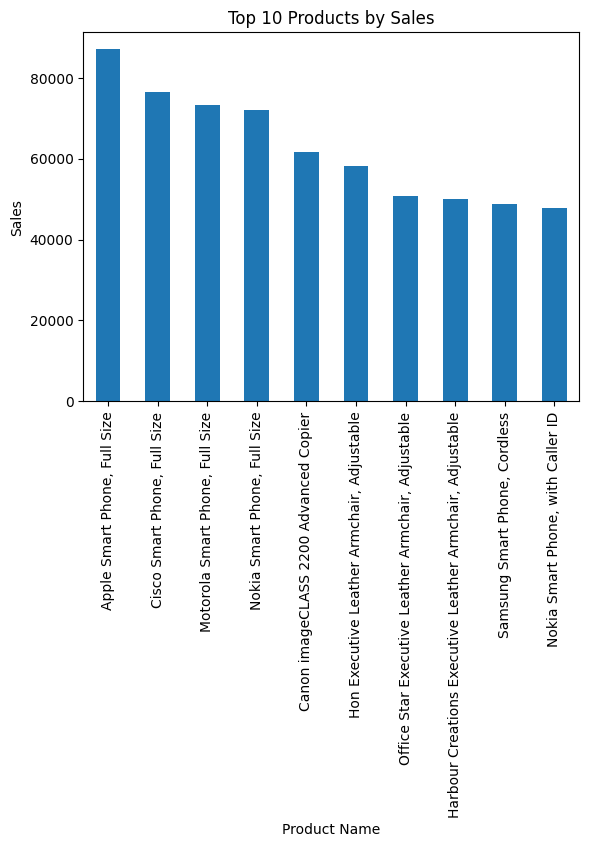

In [9]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.ylabel('Sales')
plt.show()

In [10]:
corr = df[['Sales','Profit','Quantity','Discount','Shipping Cost','Shipping Days']].corr()

print(corr)

                  Sales    Profit  Quantity  Discount  Shipping Cost  \
Sales          1.000000  0.484918  0.313577 -0.086722       0.768073   
Profit         0.484918  1.000000  0.104365 -0.316490       0.354441   
Quantity       0.313577  0.104365  1.000000 -0.019875       0.272649   
Discount      -0.086722 -0.316490 -0.019875  1.000000      -0.079056   
Shipping Cost  0.768073  0.354441  0.272649 -0.079056       1.000000   
Shipping Days -0.004660  0.001745  0.004347 -0.001507      -0.142823   

               Shipping Days  
Sales              -0.004660  
Profit              0.001745  
Quantity            0.004347  
Discount           -0.001507  
Shipping Cost      -0.142823  
Shipping Days       1.000000  
